# 07 — Compare the validation checkpoints

Epoch 5 achieved 81.0% validation accuracy. Notebook 6 selected epoch 7 at 82.8%. This notebook compares their predictions image by image to find out whether the improvement helped Bengal, caused trade-offs, or both. The official test set remains unused.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

BATCH_SIZE = 16
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SELECTED_CLASSES = ['Abyssinian', 'Bengal', 'Egyptian Mau']

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
print('This notebook compares saved predictions; it performs no training.')

PyTorch: 2.13.0+cpu
Device:  cpu
This notebook compares saved predictions; it performs no training.


In [2]:
CURRENT_FOLDER = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_FOLDER if (CURRENT_FOLDER / 'pyproject.toml').exists() else CURRENT_FOLDER.parent
METADATA_PATH = PROJECT_ROOT / 'data' / 'classification_crops' / 'metadata.csv'
EPOCH5_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_epoch5.pt'
BEST_PATH = PROJECT_ROOT / 'models' / 'part2_resnet18_frozen_head_best_epoch6_to_10.pt'

assert METADATA_PATH.exists()
assert EPOCH5_PATH.exists(), f'Missing epoch-5 checkpoint: {EPOCH5_PATH}'
assert BEST_PATH.exists(), f'Missing selected-best checkpoint: {BEST_PATH}'
records = pd.read_csv(METADATA_PATH)
val_records = records.query("split == 'val'").reset_index(drop=True)
assert len(val_records) == 58
print(f'Validation crops: {len(val_records)}')
print('No test records are loaded.')

Validation crops: 58
No test records are loaded.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PetCropDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            image = image.convert('RGB')
        return self.transform(image), int(row['label_id'])

val_loader = DataLoader(PetCropDataset(val_records, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print('The deterministic, unshuffled loader makes row 0 refer to the same crop for both checkpoints.')

The deterministic, unshuffled loader makes row 0 refer to the same crop for both checkpoints.


## Load each checkpoint and make validation predictions

Both models receive the exact same 58 input tensors. Any prediction difference therefore comes from their saved weights, not from random augmentation or a different input order.

In [4]:
def load_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
    assert checkpoint['class_names'] == SELECTED_CLASSES
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(SELECTED_CLASSES))
    model.load_state_dict(checkpoint['model_state_dict'])
    return model.to(DEVICE).eval(), checkpoint

@torch.no_grad()
def predict_ids(model):
    predicted_ids = []
    for images, _ in val_loader:
        logits = model(images.to(DEVICE))
        predicted_ids.extend(logits.argmax(dim=1).cpu().tolist())
    return predicted_ids

epoch5_model, epoch5_checkpoint = load_model(EPOCH5_PATH)
best_model, best_checkpoint = load_model(BEST_PATH)
epoch5_ids = predict_ids(epoch5_model)
best_ids = predict_ids(best_model)
best_epoch = best_checkpoint['best_epoch']

print(f'Epoch-5 validation accuracy: {(np.array(epoch5_ids) == val_records.label_id.to_numpy()).mean():.1%}')
print(f'Selected checkpoint epoch: {best_epoch}')
print(f'Selected-checkpoint validation accuracy: {(np.array(best_ids) == val_records.label_id.to_numpy()).mean():.1%}')

Epoch-5 validation accuracy: 81.0%
Selected checkpoint epoch: 7
Selected-checkpoint validation accuracy: 82.8%


In [5]:
comparison = val_records[['image_id', 'class_name', 'label_id', 'crop_path']].copy()
comparison = comparison.rename(columns={'class_name': 'true_class', 'label_id': 'true_id'})
comparison['epoch5_prediction'] = [SELECTED_CLASSES[class_id] for class_id in epoch5_ids]
comparison['epoch7_prediction'] = [SELECTED_CLASSES[class_id] for class_id in best_ids]
comparison['epoch5_correct'] = np.array(epoch5_ids) == comparison['true_id'].to_numpy()
comparison['epoch7_correct'] = np.array(best_ids) == comparison['true_id'].to_numpy()
comparison['change'] = np.select(
    [
        ~comparison['epoch5_correct'] & comparison['epoch7_correct'],
        comparison['epoch5_correct'] & ~comparison['epoch7_correct'],
        comparison['epoch5_prediction'] != comparison['epoch7_prediction'],
    ],
    ['gained (wrong to correct)', 'lost (correct to wrong)', 'changed but still wrong'],
    default='unchanged prediction',
)
display(comparison.head())

,image_id,true_class,true_id,crop_path,epoch5_prediction,epoch7_prediction,epoch5_correct,epoch7_correct,change
0,Abyssinian_101,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,Bengal,Bengal,False,False,unchanged prediction
1,Abyssinian_102,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,Abyssinian,Abyssinian,True,True,unchanged prediction
2,Abyssinian_11,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,Abyssinian,Abyssinian,True,True,unchanged prediction
3,Abyssinian_113,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,Abyssinian,Abyssinian,True,True,unchanged prediction
4,Abyssinian_119,Abyssinian,0,data/classification_crops/val/Abyssinian/Abyss...,Abyssinian,Abyssinian,True,True,unchanged prediction


In [6]:
summary = comparison['change'].value_counts().reindex([
    'gained (wrong to correct)',
    'lost (correct to wrong)',
    'changed but still wrong',
    'unchanged prediction',
], fill_value=0).rename('images').to_frame()
display(summary)

gained_or_lost = comparison.query("change != 'unchanged prediction'")
display(gained_or_lost[['image_id', 'true_class', 'epoch5_prediction', 'epoch7_prediction', 'change']])
print('A gain is good; a loss is a trade-off. The net accuracy change is gains minus losses.')

,images
change,
gained (wrong to correct),3
lost (correct to wrong),2
changed but still wrong,0
unchanged prediction,53


,image_id,true_class,epoch5_prediction,epoch7_prediction,change
23,Bengal_110,Bengal,Abyssinian,Bengal,gained (wrong to correct)
28,Bengal_130,Bengal,Abyssinian,Bengal,gained (wrong to correct)
32,Bengal_143,Bengal,Abyssinian,Bengal,gained (wrong to correct)
43,Egyptian_Mau_115,Egyptian Mau,Egyptian Mau,Bengal,lost (correct to wrong)
53,Egyptian_Mau_173,Egyptian Mau,Egyptian Mau,Bengal,lost (correct to wrong)


A gain is good; a loss is a trade-off. The net accuracy change is gains minus losses.


## Compare per-class recall

Recall answers: out of the real images of one class, what fraction did the checkpoint correctly recognise? This directly checks whether Bengal improved.

In [7]:
recall_rows = []
for class_name in SELECTED_CLASSES:
    class_rows = comparison['true_class'] == class_name
    epoch5_recall = comparison.loc[class_rows, 'epoch5_correct'].mean()
    epoch7_recall = comparison.loc[class_rows, 'epoch7_correct'].mean()
    recall_rows.append({
        'class': class_name,
        'epoch_5_recall': epoch5_recall,
        'epoch_7_recall': epoch7_recall,
        'change_in_correct_images': int(comparison.loc[class_rows, 'epoch7_correct'].sum() - comparison.loc[class_rows, 'epoch5_correct'].sum()),
    })

recall_comparison = pd.DataFrame(recall_rows).set_index('class')
display(recall_comparison.round(3))
print('Positive change means the selected checkpoint recognised more real images of that class.')

,epoch_5_recall,epoch_7_recall,change_in_correct_images
class,,,
Abyssinian,0.950,0.950,0
Bengal,0.650,0.800,3
Egyptian Mau,0.833,0.722,-2


Positive change means the selected checkpoint recognised more real images of that class.


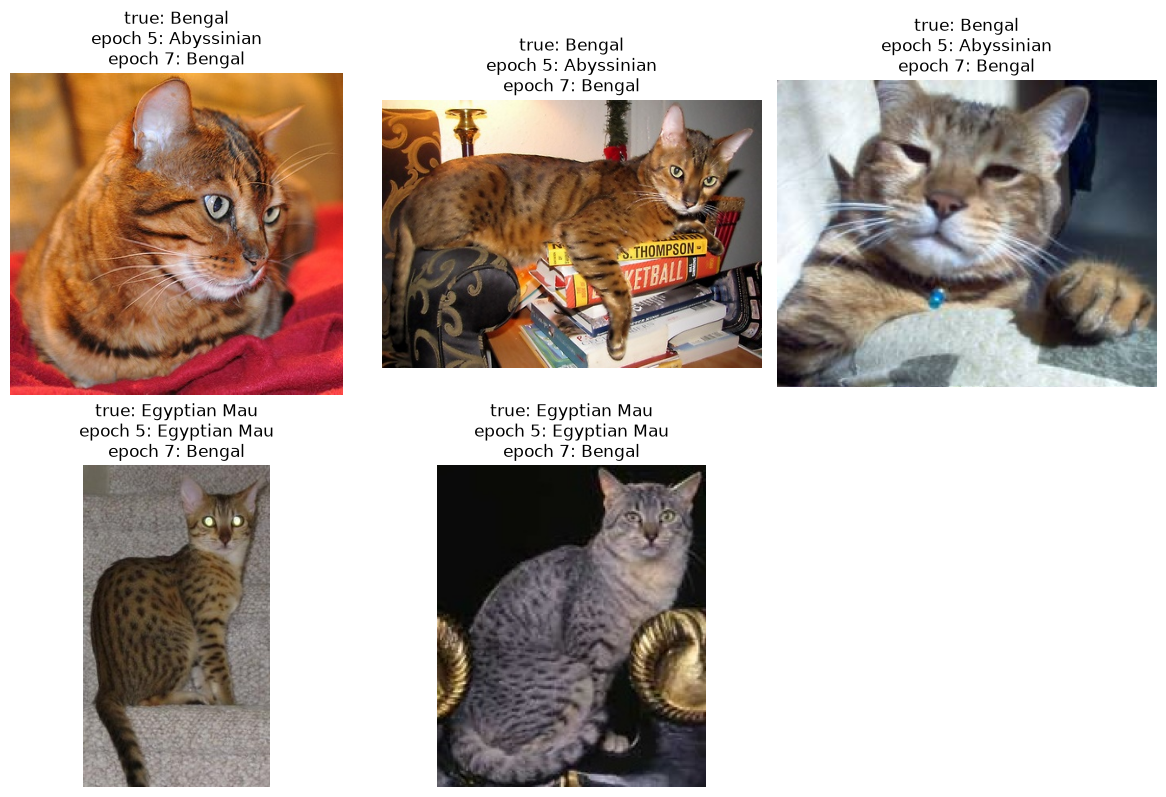

In [8]:
changed_examples = comparison.query("change != 'unchanged prediction'").reset_index(drop=True)
if changed_examples.empty:
    print('The checkpoints made identical predictions, so there are no changed images to display.')
else:
    columns = 3
    rows = int(np.ceil(len(changed_examples) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 4 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (_, row) in zip(axes, changed_examples.iterrows()):
        with Image.open(PROJECT_ROOT / row['crop_path']) as image:
            ax.imshow(image.convert('RGB'))
        ax.set_title(f"true: {row['true_class']}\nepoch 5: {row['epoch5_prediction']}\nepoch 7: {row['epoch7_prediction']}")
        ax.axis('off')
    for ax in axes[len(changed_examples):]:
        ax.axis('off')
    plt.tight_layout()
plt.show()

### Stop and decide

Send the change summary, changed-image table, per-class recall table, and the plot. We will decide whether the small epoch-7 gain justifies more fine-tuning before any test-set evaluation.